In [62]:
!python --version

Python 3.11.9


In [63]:
%matplotlib inline

In [64]:
import mne
mne.set_log_level("ERROR")

In [65]:

# EEG Config
EEG_TMIN = -0.5
EEG_TMAX = 2.0

EEG_WINDOW_START = 0.0
EEG_WINDOW_END = 2.0

# fNIRS Config
FNIRS_CHANNELS = [
    "fnirs_1",
    "fnirs_2",
    "fnirs_3",
    "fnirs_4",
    "fnirs_5",
    "fnirs_6",
    "fnirs_7",
    "fnirs_8"
]
FNIRS_FS=64
# Bandpass filter
FNIRS_LOW = 0.01
FNIRS_HIGH = 0.3

# Hemodynamic response window
FNIRS_TMIN = -2.0
FNIRS_TMAX = 15.0

FNIRS_WINDOW_START = 0.0
FNIRS_WINDOW_END = 15.0

In [66]:
import os

def define_auth():
    os.environ["HF_TOKEN"] = ""

In [67]:
import pandas as pd

def get_dataset(type="train"):
    splits = {'train': 'train_meta.csv', 'test': 'test_meta.csv'}
    df = pd.read_csv("hf://datasets/lasfk/EEG-fNIRS-based-Handwriting-Trajectory-Dataset/" + splits[type])
    return df

## EEG Extraction

In [68]:
import mne

def read_bdf(subject, session):
    path = f"../datasets/raw/{subject}/EEG/{session}.bdf"
    raw = mne.io.read_raw_bdf(path, preload=True)
    return raw

In [69]:
import numpy as np

from asrpy import ASR

def clean_bdf(raw):
    empty_channels = [
    'Fpz',
    'Fp1',
    'Fp2',
    'AF3',
    'AF4',
    'AF7',
    'AF8',
    'F7',
    'F8',
    'FT7',
    'FT8',
    'T7',
    'T8',
    'TP7',
    'TP8',
    'Pz',
    'P3',
    'P4',
    'P5',
    'P6',
    'P7',
    'P8',
    'POz',
    'PO3',
    'PO4',
    'PO5',
    'PO6',
    'PO7',
    'PO8',
    'Oz',
    'O1',
    'O2',
    'ECG',
    'HEOR',
    'HEOL',
    'VEOU',
    'VEOL',
    ]
    raw.drop_channels(empty_channels)


def segmentation_eeg(
    raw,
    onset_sec,
    label,
    tmin,
    tmax
):

    sfreq = raw.info["sfreq"]
    start_sample = int((onset_sec + tmin) * sfreq)
    end_sample = int((onset_sec + tmax) * sfreq)

    eeg_data = raw.get_data()
    n_channels = eeg_data.shape[0]

    expected_samples = int((tmax - tmin) * sfreq)


    # Left padding
    left_pad = 0
    if start_sample < 0:

        left_pad = abs(start_sample)
        start_sample = 0

    # Right padding
    right_pad = 0
    if end_sample > raw.n_times:

        right_pad = (
            end_sample - raw.n_times
        )

        end_sample = raw.n_times

    segment = eeg_data[:,start_sample:end_sample]

    # Apply padding
    if left_pad > 0 or right_pad > 0:
        segment = np.pad(
            segment,
            (
                (0, 0),
                (left_pad, right_pad)
            ),
            mode="constant",
            constant_values=0

        )

    # Safety check
    if segment.shape[1] != expected_samples:
        segment = segment[:, :expected_samples]
    return segment, label


def normalize_channel(X):
    X_norm = np.zeros_like(X)

    for i in range(X.shape[0]):
    
        for ch in range(X.shape[1]):
    
            signal = X[i, ch]
    
            mean = signal.mean()
            std = signal.std()
    
            if std == 0:
                std = 1e-8
    
            X_norm[i, ch] = (signal - mean) / std
    return X_norm

def asr_remove(raw):
    sfreq = raw.info["sfreq"]
    asr = ASR(
        sfreq=sfreq,
        cutoff=20
    )
    asr.fit(raw)
    clean_data = asr.transform(raw)
    return mne.io.RawArray(clean_data, raw.info)

def preprocessing_bdf(raw):
    clean_bdf(raw)

    # Buang sinyal listrik
    raw.notch_filter(50)

    # Band Pass 1Hz~45Hz, Band EEG umum => Delta, Theta, Alpha, Beta, Gamma (1 - 45)Hz
    raw.filter(0.5, 45)
    return raw

## fNIRS Extraction

In [70]:
import pandas as pd

def read_fnirs(subject, session):
    path = f"../datasets/raw/{subject}/fNIRS/{session}.csv"
    fnirs = pd.read_csv(path)
    return fnirs

In [71]:
import numpy as np

from scipy.signal import butter
from scipy.stats import median_abs_deviation
from sklearn.decomposition import PCA

from scipy.signal import butter
from scipy.signal import sosfiltfilt

def segmentation_fnirs(
    df_fnirs,
    onset_sec,
    label,
    tmin,
    tmax,
    fs
):
    start_sample = int((onset_sec + tmin) * fs)
    end_sample = int((onset_sec + tmax) * fs)

    
    fnirs_data = df_fnirs
    n_channels = fnirs_data.shape[0]

    expected_samples = int((tmax - tmin) * fs)

    # left padding
    left_pad = 0
    if start_sample < 0:
        left_pad = abs(start_sample)
        start_sample = 0

    # right padding
    right_pad = 0
    if end_sample > fnirs_data.shape[1]:

        right_pad = (end_sample - fnirs_data.shape[1])
        end_sample = fnirs_data.shape[1]

    segment = fnirs_data[:, start_sample:end_sample]

    # apply padding
    if left_pad > 0 or right_pad > 0:

        segment = np.pad(
            segment,
            (
                (0, 0),
                (left_pad, right_pad)
            ),
            mode="constant",
            constant_values=0

        )

    # safety
    if segment.shape[1] != expected_samples:
        segment = segment[:, :expected_samples]
    return segment, label


def bandpass_fnirs(
    signal,
    fs=FNIRS_FS,
    lowcut=FNIRS_LOW,
    highcut=FNIRS_HIGH,
    order=4
):

    signal = np.nan_to_num(
        signal,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    nyquist = fs / 2

    low = lowcut / nyquist
    high = highcut / nyquist

    sos = butter(
        order,
        [low, high],
        btype="bandpass",
        output="sos"
    )

    filtered = sosfiltfilt(
        sos,
        signal
    )

    filtered = np.nan_to_num(
        filtered,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    return filtered

def remove_global_pca(fnirs_data):
    pca = PCA(n_components=fnirs_data.shape[0])
    transformed = pca.fit_transform(
        fnirs_data.T
    )
    transformed[:, 0] = 0
    reconstructed = pca.inverse_transform(transformed).T
    return reconstructed

def preprocessing_fnirs(fnirs_data, fs):
    if isinstance(fnirs_data, pd.DataFrame):
        fnirs_data = fnirs_data.values.T

    processed = fnirs_data.copy()
    for ch in range(processed.shape[0]):
        signal = processed[ch]
        signal = bandpass_fnirs(
            signal,
            fs=fs,
            lowcut=0.01,
            highcut=0.3
        )
        processed[ch] = signal
    return remove_global_pca(processed)

## Extract Features

In [72]:
define_auth()
df_train = get_dataset(type="train")

print(df_train.head())

      trial_id subject  session  onset_sec  event_code  label
0  sub_01_1_00  sub_01        1     25.060         203      3
1  sub_01_1_01  sub_01        1     49.410         201      1
2  sub_01_1_02  sub_01        1     73.870         201      1
3  sub_01_1_03  sub_01        1     98.695         201      1
4  sub_01_1_04  sub_01        1    123.850         202      2


### Extract Features EEG & fNIRS

In [75]:
import numpy as np
from tqdm import tqdm
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.model_selection import (
    train_test_split
)
from sklearn.preprocessing import (
    StandardScaler
)
from scipy.signal import (
    resample
)


X_feature = []
y_feature = []
subject_ids = []

subjects = sorted(
    df_train["subject"].unique()
)

for subject in tqdm(subjects):
    # Filter data train with subject
    subject_df = df_train[df_train["subject"] == subject]

    sessions = sorted(subject_df["session"].unique())

    for session in sessions:

        # EEG Parts
        raw = read_bdf(subject, session)
        raw = preprocessing_bdf(raw)

        # fNIRS Parts
        df_fnirs = read_fnirs(subject, session)
        df_fnirs = preprocessing_fnirs(df_fnirs, FNIRS_FS)

        # Filter by session & subjects
        session_df = subject_df[
            subject_df["session"] == session
        ]

        for _, row in session_df.iterrows():

            onset_sec = row["onset_sec"]
            label = int(row["label"])


            # EEG Segmentation
            segment_eeg, _ = segmentation_eeg(
                raw,
                onset_sec,
                label,
                EEG_TMIN,
                EEG_TMAX
            )

            # fNIRS Segmentation
            segment_fnirs, _ = segmentation_fnirs(
                df_fnirs,
                onset_sec,
                label,
                FNIRS_TMIN,
                FNIRS_TMAX,
                FNIRS_FS
            )


            # Validate EEG
            EXPECTED_EEG_SAMPLES = int((EEG_TMAX - EEG_TMIN) * raw.info["sfreq"])
            if (segment_eeg is None or segment_eeg.shape[1] != EXPECTED_EEG_SAMPLES):
                continue

            # Validate fNIRS
            EXPECTED_FNIRS_SAMPLES = int((FNIRS_TMAX - FNIRS_TMIN) * FNIRS_FS)
            if (segment_fnirs is None or segment_fnirs.shape[1] != EXPECTED_FNIRS_SAMPLES):
                continue

            
            segment_eeg = np.nan_to_num(segment_eeg)
            segment_fnirs = np.nan_to_num(segment_fnirs)

            # Normalize: Z-score normalization
            eeg_mean = segment_eeg.mean(axis=1, keepdims=True)
            eeg_std = segment_eeg.std(axis=1,keepdims=True)
            segment_eeg = (segment_eeg - eeg_mean) / (eeg_std + 1e-8)
            
            fnirs_mean = segment_fnirs.mean(axis=1, keepdims=True)
            fnirs_std = segment_fnirs.std(axis=1, keepdims=True)
            segment_fnirs = (segment_fnirs - fnirs_mean) / (fnirs_std + 1e-8)

            # EEG Window
            eeg_times = np.linspace(EEG_TMIN, EEG_TMAX, segment_eeg.shape[1])
            eeg_mask = ((eeg_times >= EEG_WINDOW_START) & (eeg_times <= EEG_WINDOW_END))
            eeg_window = segment_eeg[:,eeg_mask]
            EEG_TARGET_SAMPLES = 64
            eeg_pooled = resample(
                eeg_window,
                EEG_TARGET_SAMPLES,
                axis=1
            
            )

            # fNIRS Window
            fnirs_times = np.linspace(FNIRS_TMIN, FNIRS_TMAX, segment_fnirs.shape[1])
            fnirs_mask = ((fnirs_times >= FNIRS_WINDOW_START) & (fnirs_times <= FNIRS_WINDOW_END))
            fnirs_window = segment_fnirs[:, fnirs_mask]
            FNIRS_TARGET_SAMPLES = 32
            fnirs_pooled = resample(
                fnirs_window,
                FNIRS_TARGET_SAMPLES,
                axis=1
            
            )

            # Flatten raw temporal feature
            eeg_feat = eeg_pooled.flatten()
            fnirs_feat = fnirs_pooled.flatten()

            # Multimodal feature
            feature = np.concatenate([eeg_feat, fnirs_feat])


            X_feature.append(feature)
            y_feature.append(label)
            subject_ids.append(subject)


X_feature = np.array(X_feature)
y_feature = np.array(y_feature)
subject_ids = np.array(subject_ids)


print("\nX_feature Shape")
print(X_feature.shape)

print("\ny_feature Shape")
print(y_feature.shape)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [09:25<00:00, 28.26s/it]


X_feature Shape
(6426, 2016)

y_feature Shape
(6426,)


In [76]:
import numpy as np

from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.model_selection import (
    train_test_split
)

from sklearn.preprocessing import (
    StandardScaler
)

from sklearn.decomposition import (
    PCA
)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_feature,
    y_feature,
    test_size=0.2,
    random_state=42,
    stratify=y_feature
)

print("\nBefore PCA")
print(X_train.shape)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

pca = PCA(n_components=0.95)

X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

print("\nAfter PCA")
print(X_train.shape)

print("\nExplained Variance:")

print(np.sum(pca.explained_variance_ratio_))

# Init model Linear SVM
svm = LinearSVC(
    C=1.0,
    max_iter=10000
)

# Training
svm.fit(X_train, y_train)


# Predict
y_pred = svm.predict(X_test)

# Accuracy
acc = accuracy_score(y_test,y_pred)
print("\n==============================")
print("LINEAR SVM + PCA RESULT")
print("==============================")
print("Accuracy:", round(acc, 4))



# Classification Report
print("\nClassification Report")

print(classification_report(y_test, y_pred))



# Confustion Matrix
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))


Before PCA
(5140, 2016)

After PCA
(5140, 370)

Explained Variance:
0.9501407673967008

LINEAR SVM + PCA RESULT
Accuracy: 0.4821

Classification Report
              precision    recall  f1-score   support

           0       0.45      0.48      0.46       321
           1       0.46      0.44      0.45       322
           2       0.54      0.54      0.54       322
           3       0.48      0.47      0.47       321

    accuracy                           0.48      1286
   macro avg       0.48      0.48      0.48      1286
weighted avg       0.48      0.48      0.48      1286


Confusion Matrix
[[153  73  39  56]
 [ 73 143  51  55]
 [ 54  40 173  55]
 [ 58  57  55 151]]


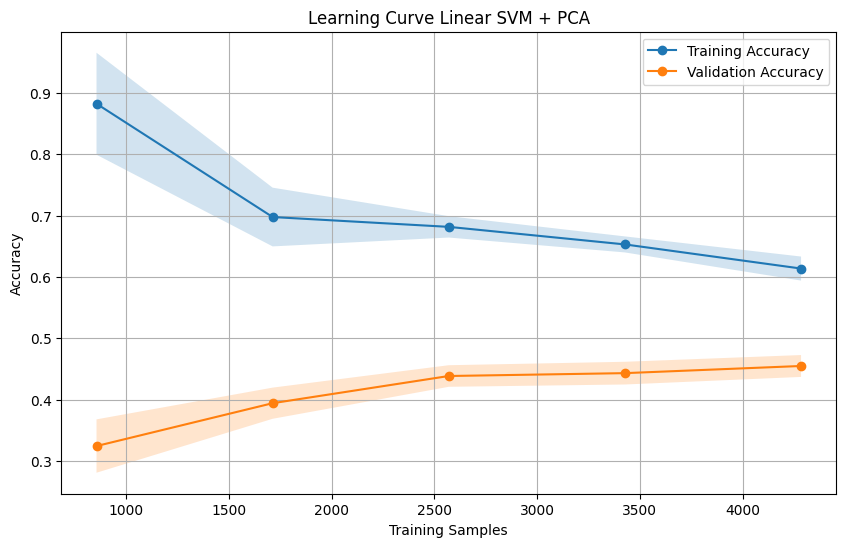

In [77]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline

from sklearn.model_selection import (
    learning_curve
)

from sklearn.preprocessing import (
    StandardScaler
)

from sklearn.decomposition import (
    PCA
)

from sklearn.svm import (
    LinearSVC
)

# Pipeline
pipeline = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "pca",
        PCA(
            n_components=0.95
        )
    ),
    (
        "svm",
        LinearSVC(
            C=1.0,
            max_iter=10000,
            random_state=42
        )
    )
])


train_sizes, train_scores, val_scores = learning_curve( 
    estimator=pipeline,
    X=X_feature, 
    y=y_feature, 
    cv=3, 
    scoring="accuracy", 
    train_sizes=np.linspace( 0.2, 1.0, 5 ), 
    n_jobs=1 
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)

val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(
    train_sizes,
    train_mean,
    marker="o",
    label="Training Accuracy"
)
plt.plot(
    train_sizes,
    val_mean,
    marker="o",
    label="Validation Accuracy"
)


plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)

plt.fill_between(
    train_sizes,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.2
)

# =====================================================
# STYLE
# =====================================================

plt.title("Learning Curve Linear SVM + PCA")
plt.xlabel("Training Samples")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()
plt.show()


In [80]:
import numpy as np

def inference(raw, df_fnirs, onset_sec):
    # segmentation function butuh label
    dummy_label = 0

    # EEG Segmentation
    segment_eeg, _ = segmentation_eeg(
        raw,
        onset_sec,
        dummy_label,
        EEG_TMIN,
        EEG_TMAX
    )

    # fNIRS Segmentation
    segment_fnirs, _ = segmentation_fnirs(
        df_fnirs,
        onset_sec,
        dummy_label,
        FNIRS_TMIN,
        FNIRS_TMAX,
        FNIRS_FS
    )

    # Validate
    EXPECTED_EEG_SAMPLES = int((EEG_TMAX - EEG_TMIN) * raw.info["sfreq"])
    EXPECTED_FNIRS_SAMPLES = int((FNIRS_TMAX - FNIRS_TMIN) * FNIRS_FS)

    if (segment_eeg is None or segment_eeg.shape[1] != EXPECTED_EEG_SAMPLES ): 
        if segment_eeg is None: 
            n_channels = len( EEG_CHANNELS ) 
            segment_eeg = np.zeros( ( n_channels, EXPECTED_EEG_SAMPLES ) ) 
        else: 
            current_samples = segment_eeg.shape[1] 
            missing = ( EXPECTED_EEG_SAMPLES - current_samples ) 
            if missing > 0: 
                segment_eeg = np.pad( segment_eeg, ( (0, 0), (0, missing) ), mode="constant", constant_values=0 ) 
            else: 
                segment_eeg = segment_eeg[ :, :EXPECTED_EEG_SAMPLES ] 
                
    if ( segment_fnirs is None or segment_fnirs.shape[1] != EXPECTED_FNIRS_SAMPLES ): 
        if segment_fnirs is None: 
            n_channels = len( FNIRS_CHANNELS ) 
            segment_fnirs = np.zeros( ( n_channels, EXPECTED_FNIRS_SAMPLES ) ) 
        else: 
            current_samples = segment_fnirs.shape[1] 
            missing = ( EXPECTED_FNIRS_SAMPLES - current_samples ) 
            if missing > 0: 
                segment_fnirs = np.pad( segment_fnirs, ( (0, 0), (0, missing) ), mode="constant", constant_values=0 ) 
            else: 
                segment_fnirs = segment_fnirs[ :, :EXPECTED_FNIRS_SAMPLES ]
    
    segment_eeg = np.nan_to_num(segment_eeg)
    segment_fnirs = np.nan_to_num(segment_fnirs)


     # Normalize: Z-score normalization
    eeg_mean = segment_eeg.mean(axis=1, keepdims=True)
    eeg_std = segment_eeg.std(axis=1,keepdims=True)
    segment_eeg = (segment_eeg - eeg_mean) / (eeg_std + 1e-8)
    
    fnirs_mean = segment_fnirs.mean(axis=1, keepdims=True)
    fnirs_std = segment_fnirs.std(axis=1, keepdims=True)
    segment_fnirs = (segment_fnirs - fnirs_mean) / (fnirs_std + 1e-8)

    # EEG Window
    eeg_times = np.linspace(EEG_TMIN, EEG_TMAX, segment_eeg.shape[1])
    eeg_mask = ((eeg_times >= EEG_WINDOW_START) & (eeg_times <= EEG_WINDOW_END))
    eeg_window = segment_eeg[:,eeg_mask]
    EEG_TARGET_SAMPLES = 64
    eeg_pooled = resample(
        eeg_window,
        EEG_TARGET_SAMPLES,
        axis=1
    
    )

    # fNIRS Window
    fnirs_times = np.linspace(FNIRS_TMIN, FNIRS_TMAX, segment_fnirs.shape[1])
    fnirs_mask = ((fnirs_times >= FNIRS_WINDOW_START) & (fnirs_times <= FNIRS_WINDOW_END))
    fnirs_window = segment_fnirs[:, fnirs_mask]
    FNIRS_TARGET_SAMPLES = 32
    fnirs_pooled = resample(
        fnirs_window,
        FNIRS_TARGET_SAMPLES,
        axis=1
    
    )

    # Flatten raw temporal feature
    eeg_feat = eeg_pooled.flatten()
    fnirs_feat = fnirs_pooled.flatten()

    # Multimodal feature
    feature = np.concatenate([eeg_feat, fnirs_feat])
    feature = feature.reshape(1, -1)
    feature = scaler.transform(feature)

    # PCA
    feature = pca.transform(feature)

    # Predict
    pred = svm.predict(
        feature
    )
    predicted_class = int(
        pred[0]
    )
    return predicted_class


## Submission

In [81]:
import pandas as pd

df_test = get_dataset(type="test")
print(df_test.head())

      trial_id subject  session  onset_sec
0  sub_21_1_00  sub_21        1     24.495
1  sub_21_1_01  sub_21        1     49.347
2  sub_21_1_02  sub_21        1     74.205
3  sub_21_1_03  sub_21        1     99.075
4  sub_21_1_04  sub_21        1    123.933


In [82]:
import numpy as np
import pandas as pd

from tqdm import tqdm

last_subject = None
last_session = None

cached_raw = None
cached_fnirs = None


predictions = []
trial_ids = []

for _, row in tqdm(df_test.iterrows(), total=len(df_test)):

    subject = row["subject"]
    session = row["session"]
    onset_sec = row["onset_sec"]
    trial_id = row["trial_id"]

    if (last_subject != subject or last_session != session):
        raw = read_bdf(subject, session)
        raw = preprocessing_bdf(raw)

        df_fnirs = read_fnirs(subject, session)
        df_fnirs = preprocessing_fnirs(df_fnirs, FNIRS_FS)

        cached_raw = raw
        cached_fnirs = df_fnirs
        last_subject = subject
        last_session = session

        y_pred = inference(
            raw=cached_raw,
            df_fnirs=cached_fnirs,
            onset_sec=onset_sec
        )

    predictions.append(y_pred)
    trial_ids.append(trial_id)

predictions = np.array(predictions)

submission = pd.DataFrame({
    "trial_id": trial_ids,
    "label": predictions
})
print(submission.head())

submission.to_csv("nlinear_svm_pca_002.csv", index=False)
print("\nlinear_svm_pca_002.csv saved!")



100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3238/3238 [03:09<00:00, 17.05it/s]

      trial_id  label
0  sub_21_1_00      2
1  sub_21_1_01      2
2  sub_21_1_02      2
3  sub_21_1_03      2
4  sub_21_1_04      2

linear_svm_pca_002.csv saved!
